# DDM of uio.tif

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma #special function for rescaling tau
import pandas as pd

In [2]:
import numpy as np #numerical python used for working with arrays, mathematical operations
import xarray as xr #package for labeling and adding metadata to multi-dimensional arrays

In [3]:
import sys
sys.path.append("F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM") #must point to the PyDDM folder
import ddm_analysis_and_fitting as ddm

nd2reader module not found. Reading of .nd2 files disabled.


In [4]:
import os
import xarray as xr

# Define folder path where YAML files are stored
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"

# Loop through each YAML file in the folder
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):  # Process only YAML files
        yaml_path = os.path.join(yaml_folder, yaml_file)

        # Step 1: Initialize DDM analysis with the current YAML file
        ddm_calc = ddm.DDM_Analysis(yaml_path)

        # Step 2: Calculate the DDM matrix
        ddm_calc.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 3: Perform the initial fit
        ddm_fit = ddm.DDM_Fit(ddm_calc.data_yaml)
        fit01 = ddm_fit.fit()

        # Step 4: Generate the fit report
        ddm.fit_report(fit01, q_indices=[8, 12, 16, 20], forced_qs=[8, 20], use_new_tau=True, show=True)

        # Step 5: Reload the fit model and perform another fit
        ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
        fit01b = ddm_fit.fit(display_table=False)
        ddm.fit_report(fit01b, q_indices=[5,10,15,30], forced_qs=[8,30], use_new_tau=True, show=True)

         # Step 6: Save the fit result (fit01b) as a NetCDF file with the same name as the YAML file but with .nc extension
        netcdf_filename = os.path.splitext(yaml_file)[0] + ".nc"
        netcdf_filepath = os.path.join(yaml_folder, netcdf_filename)
        fit01b.to_netcdf(netcdf_filepath, engine="netcdf4")

        # Optional: Print confirmation of save
        print(f"Fit results saved for {yaml_file} as {netcdf_filepath}")

        # Step 7: Load the saved NetCDF file to extract parameters
        ddm_fit_data = xr.load_dataset(netcdf_filepath)

        # Extract 'Tau' (decay time) and 'q' values
        tau = ddm_fit_data.parameters.loc['Tau']
        q_values = ddm_fit_data.q

        # Step 8: Plot Tau vs. q for this file
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.loglog(q_values, tau, 'ro-', label='Tau (decay time) vs q')
        
        # Customize the plot
        ax.set_xlabel("q ($\mu$m$^{-1}$)")
        ax.set_ylabel("Decay time, Tau (s)")
        ax.set_title(f"Decay Time vs q for {yaml_file}")
        ax.legend()

        # Step 9: Save and show the plot as a PNG image
        plot_filename = os.path.splitext(yaml_file)[0] + "_decay_time_vs_q.png"
        plot_filepath = os.path.join(yaml_folder, plot_filename)
        plt.savefig(plot_filepath)
        plt.show()

        # Optional: Print confirmation of save
        print(f"Decay time vs q plot saved for {yaml_file} as {plot_filepath}")

        # Close the figure to avoid memory issues when processing multiple files
        plt.close(fig)

       

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
C:\Users\rsaldanha\AppData\Local\Temp\ipykernel_25224\3268692842.py:50: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("q ($\mu$m$^{-1}$)")


Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc ...
In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit01'.


...

In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 


,Initial guess,Minimum,Maximum
Tau,1.0,0.001,10000.0
StretchingExp,1.0,0.500,1.8


In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit02'.
In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 


C:\Users\rsaldanha\AppData\Local\Temp\ipykernel_25224\3268692842.py:50: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("q ($\mu$m$^{-1}$)")


ModuleNotFoundError: No module named 'netCDF4'

Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt15-1_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt15-1_ddmmatrix.nc ...
In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit01'.


,q,Amplitude,Tau,Background,StretchingExp
0,0.000000,100.000000,1.000000,25000.000000,1.000000
1,0.144375,10000.000000,3006.563926,37.321316,1.218398
2,0.288749,10000.000000,7099.472690,34.203894,1.122425
3,0.433124,9999.999998,3262.839526,34.752373,1.268998
4,0.577499,5119.311724,10000.000000,32.952203,0.911957
5,0.721873,8799.287868,10000.000000,33.276341,0.994176
6,0.866248,5296.983972,10000.000000,33.088504,0.913413
7,1.010623,5130.185728,10000.000000,33.069484,0.915613
8,1.154997,3587.776119,10000.000000,32.938946,0.849839
9,1.299372,2805.253721,10000.000000,33.056597,0.821519


In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 


,Initial guess,Minimum,Maximum
Tau,1.0,0.001,10000.0
StretchingExp,1.0,0.500,1.8


In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit02'.
In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 
Fit results saved for wt15-1.yml as F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\wt15-1_fit_results.csv


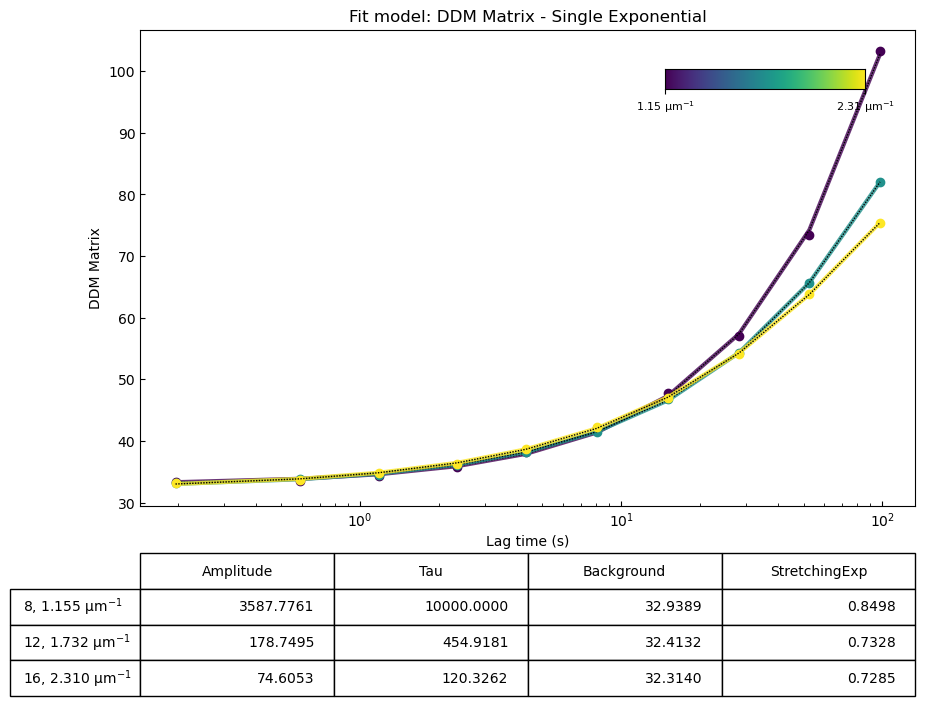

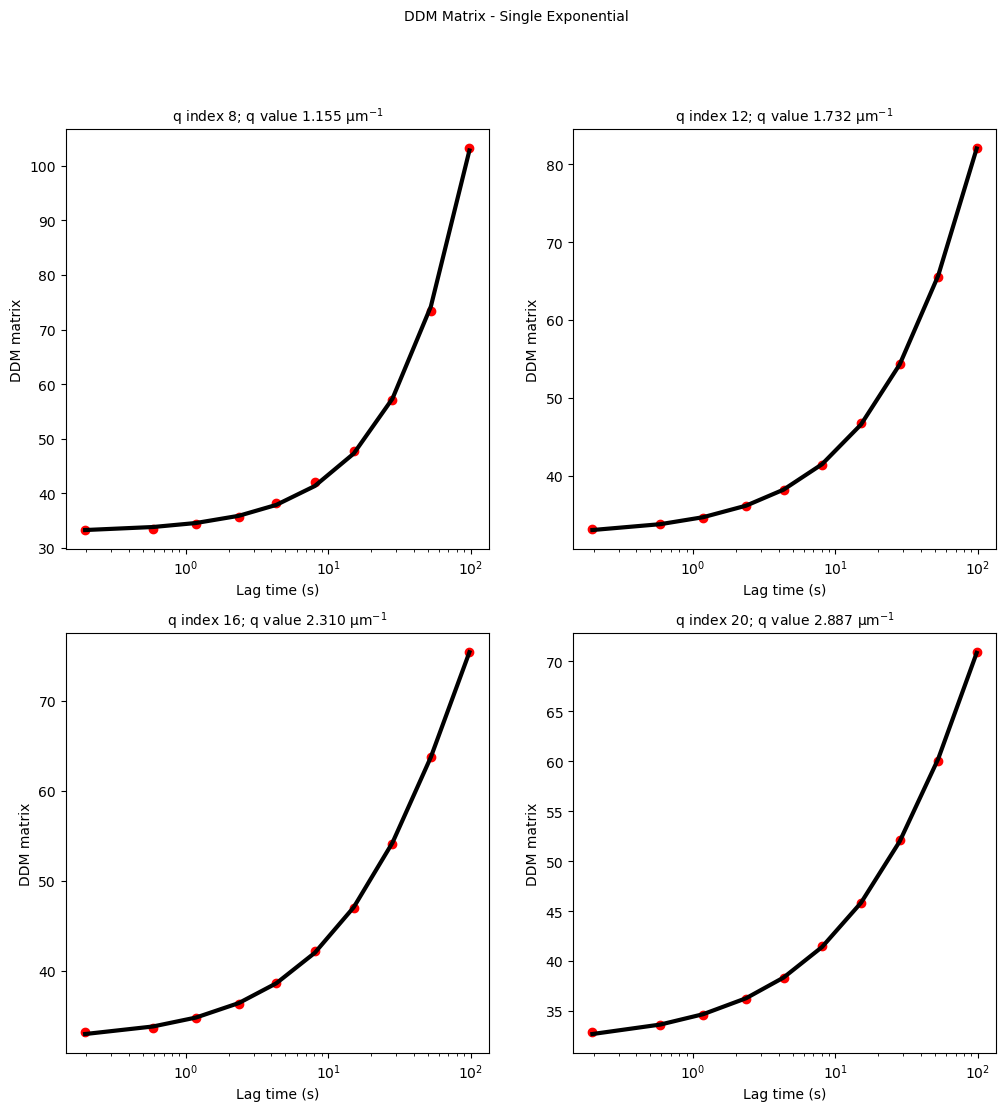

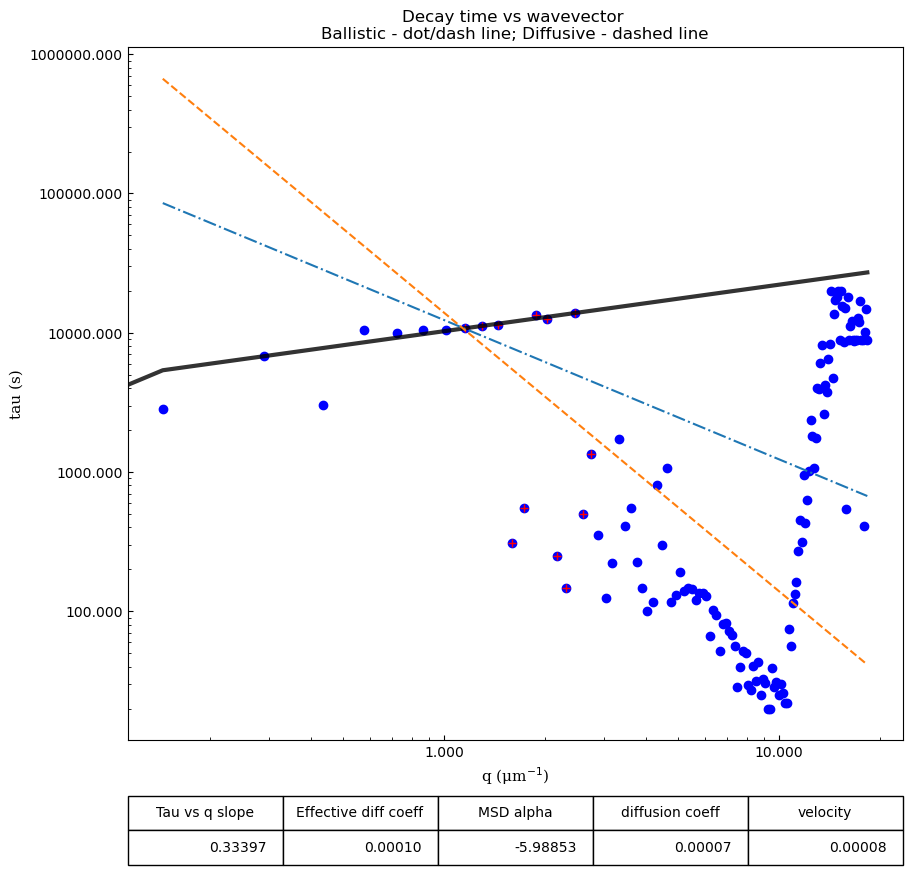

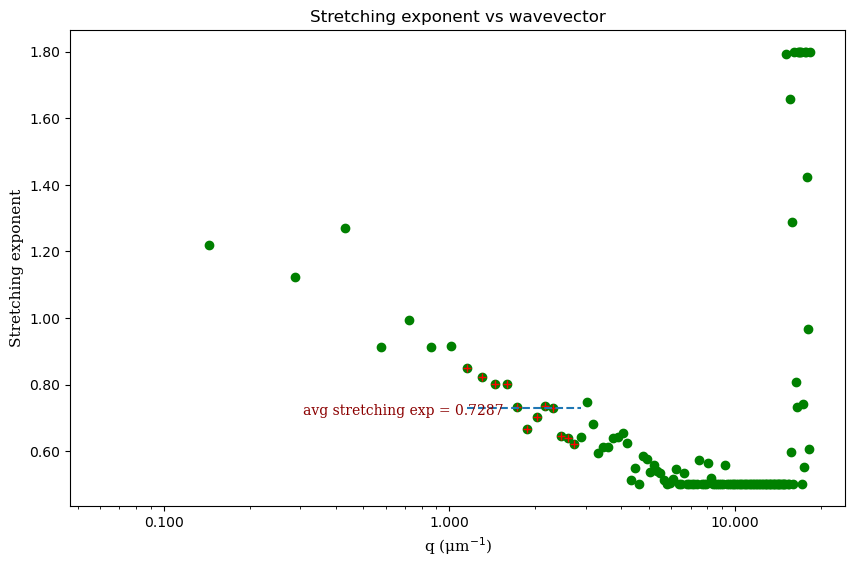

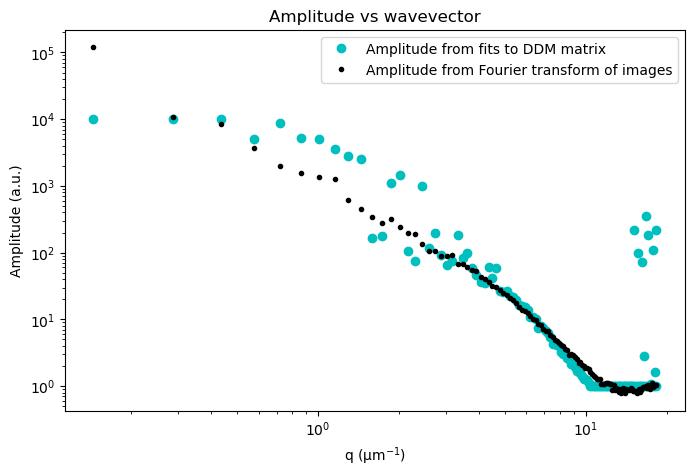

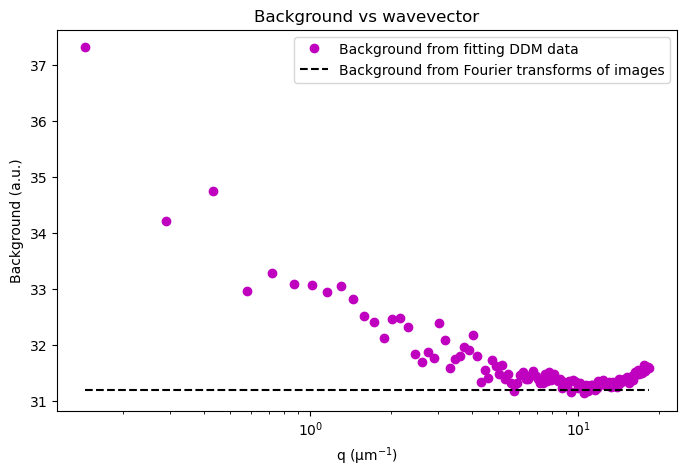

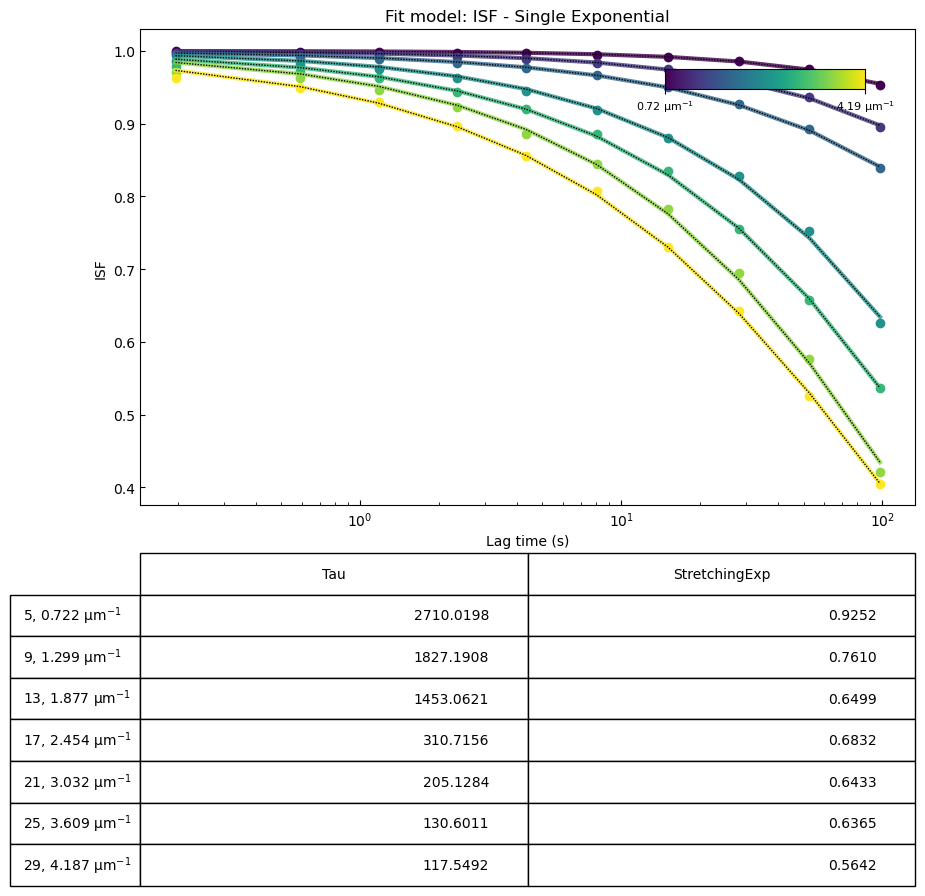

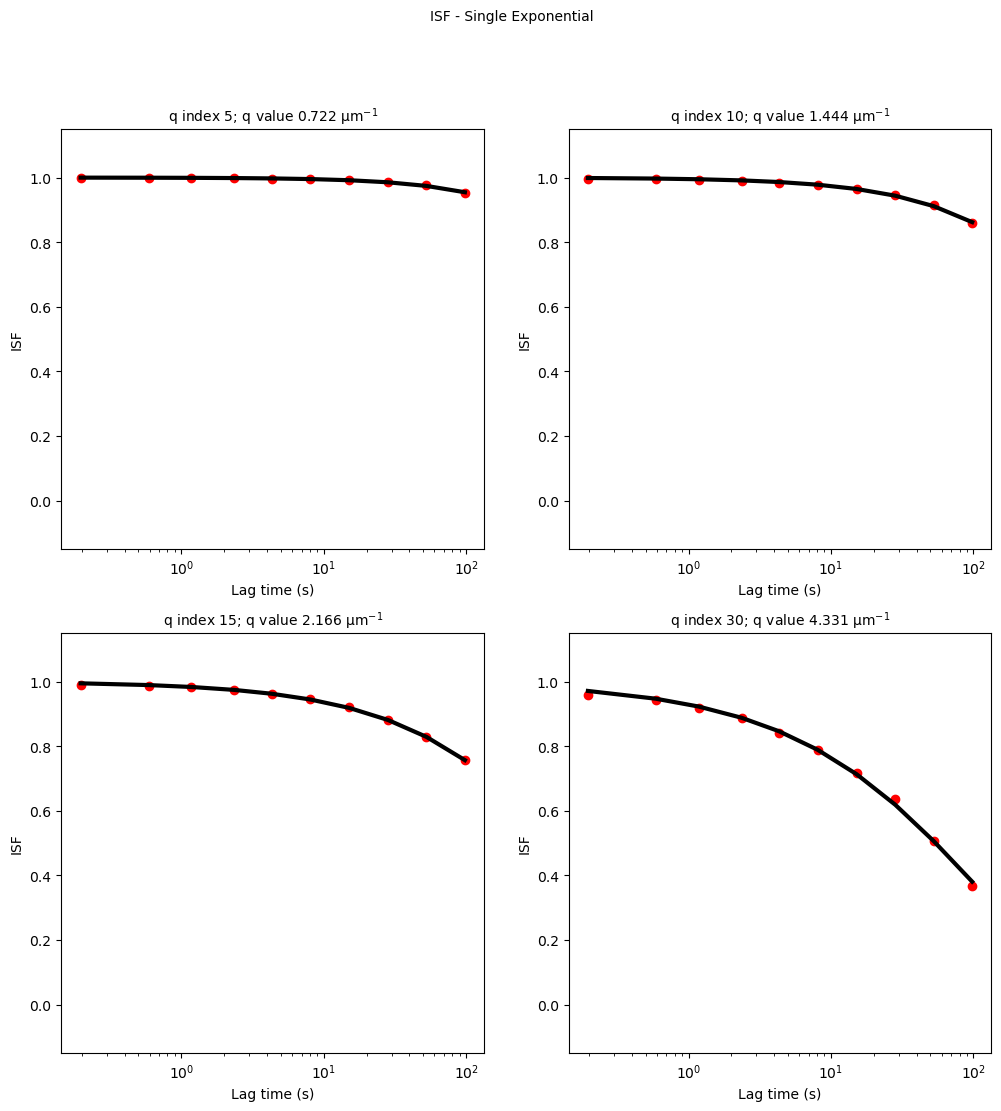

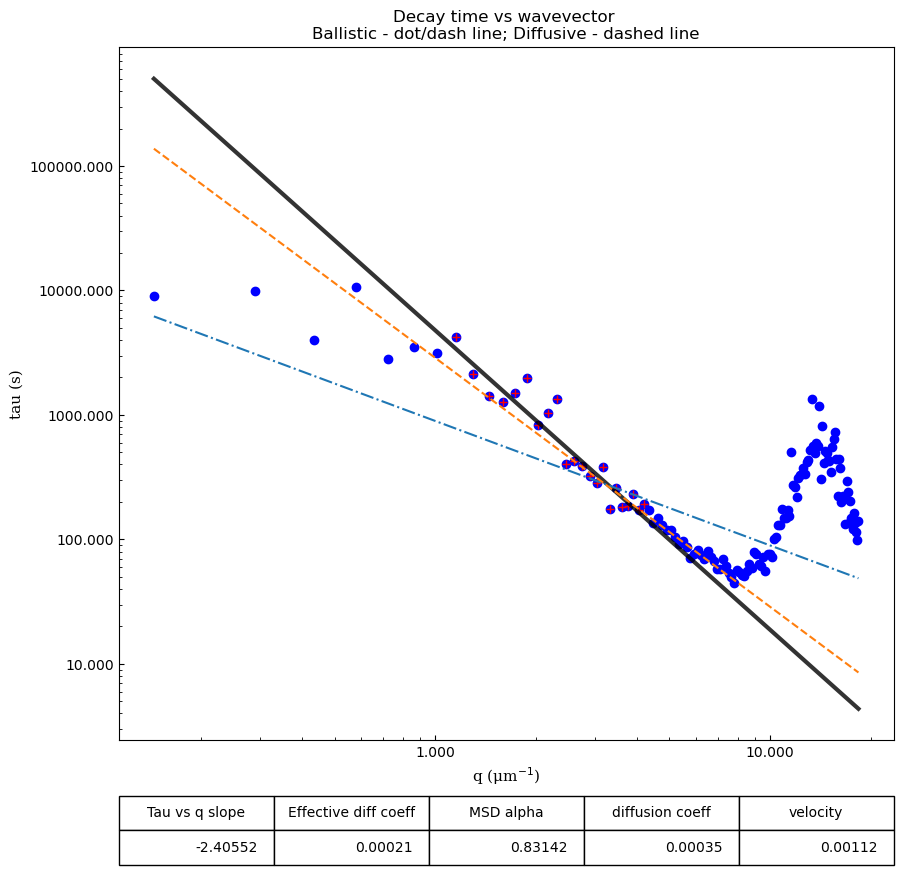

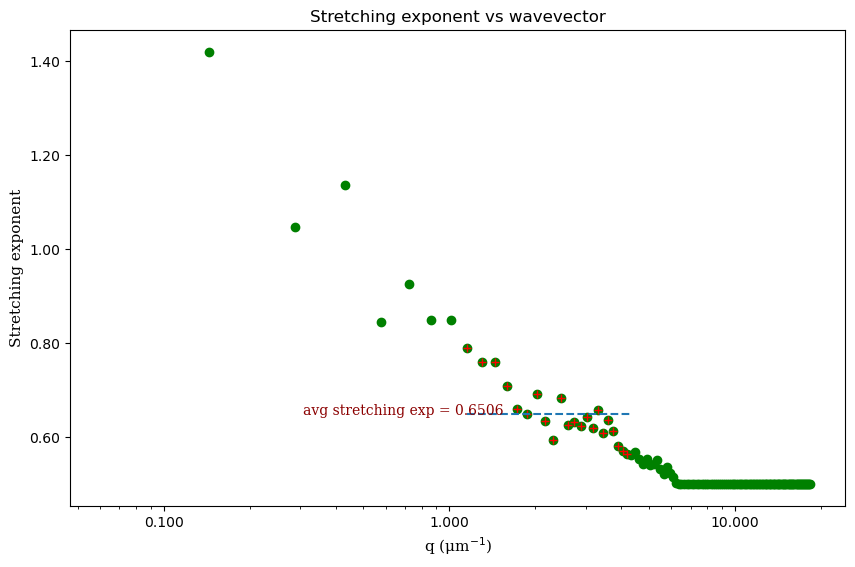

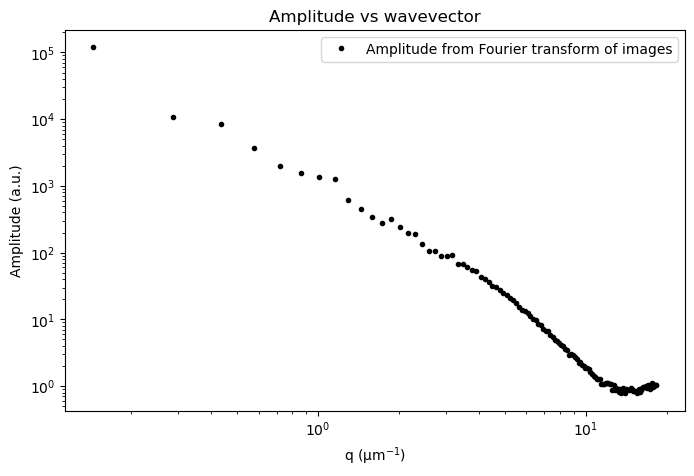

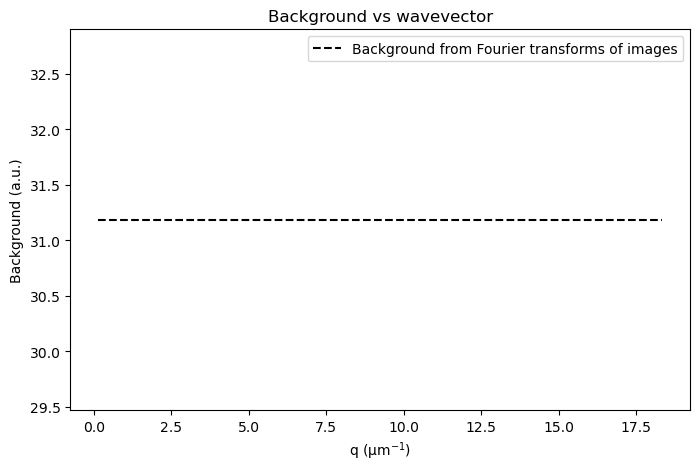

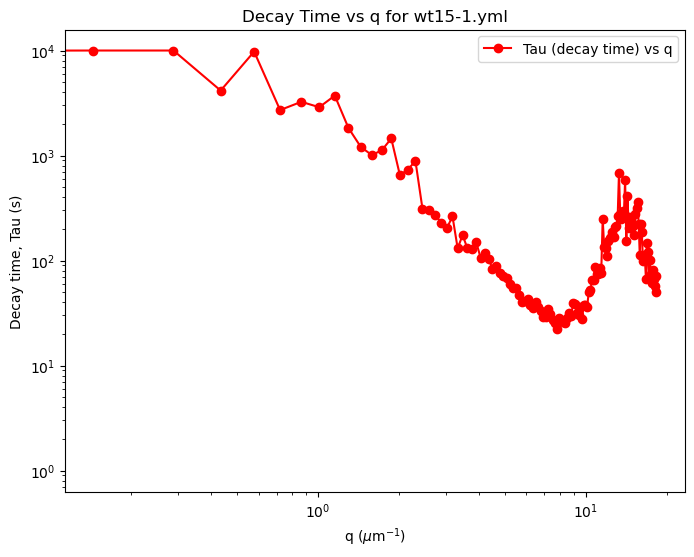

Decay time vs q plot saved for wt15-1.yml as F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\wt15-1_decay_time_vs_q.png
Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


In [ ]:
#working code
import os
import xarray as xr

# Define folder path where YAML files are stored
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"

# Loop through each YAML file in the folder
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)

        # Step 1: Initialize DDM analysis with the current YAML file
        ddm_calc = ddm.DDM_Analysis(yaml_path)

        # Step 2: Calculate the DDM matrix
        ddm_calc.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 3: Perform the initial fit
        ddm_fit = ddm.DDM_Fit(ddm_calc.data_yaml)
        fit01 = ddm_fit.fit()

        # Step 4: Generate the fit report
        ddm.fit_report(fit01, q_indices=[8, 12, 16, 20], forced_qs=[8, 20], use_new_tau=True, show=True)

        # Step 5: Reload the fit model and perform another fit
        ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
        fit01b = ddm_fit.fit(display_table=False)
        ddm.fit_report(fit01b, q_indices=[5,10,15,30], forced_qs=[8,30], use_new_tau=True, show=True)

        # Step 6: Extract fit results and save as CSV
        try:
            tau = fit01b.parameters.loc['Tau'].values
            q_values = fit01b.q.values
            result_df = pd.DataFrame({"q": q_values, "Tau": tau})
            csv_filename = os.path.splitext(yaml_file)[0] + "_fit_results.csv"
            csv_filepath = os.path.join(yaml_folder, csv_filename)
            result_df.to_csv(csv_filepath, index=False)
            print(f"Fit results saved for {yaml_file} as {csv_filepath}")
        except Exception as e:
            print(f"Error extracting parameters from {yaml_file}: {e}")
            continue

        # Step 7: Plot Tau vs. q
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.loglog(q_values, tau, 'ro-', label='Tau (decay time) vs q')
        ax.set_xlabel("q ($\\mu$m$^{-1}$)")
        ax.set_ylabel("Decay time, Tau (s)")
        ax.set_title(f"Decay Time vs q for {yaml_file}")
        ax.legend()

        # Step 8: Save plot
        plot_filename = os.path.splitext(yaml_file)[0] + "_decay_time_vs_q.png"
        plot_filepath = os.path.join(yaml_folder, plot_filename)
        plt.savefig(plot_filepath)
        plt.show()
        plt.close(fig)

    
        print(f"Decay time vs q plot saved for {yaml_file} as {plot_filepath}")


We have a few options for saving the results of the fit. We can save the information contained in the xarray Dataset `fit01` as an Excel file. Or we can save it as a netCDF file using the xarray function [`to_netcdf`](https://xarray.pydata.org/en/stable/generated/xarray.Dataset.to_netcdf.html). If we have the fit results as a netCDF file, then we can reload it easily with the xarray function [`open_dataset`](https://xarray.pydata.org/en/stable/generated/xarray.open_dataset.html). 

In [11]:
import os
import xarray as xr


# Define folder path
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"

# Define q indices to use in fit plots
selected_q_indices = [5, 10, 15, 30]

# Loop over YAMLs
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)

        # Step 1: Load YAML and run DDM
        ddm_calc = ddm.DDM_Analysis(yaml_path)
        ddm_calc.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 2: Fit model
        ddm_fit = ddm.DDM_Fit(ddm_calc.data_yaml)
        ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
        fit01b = ddm_fit.fit(display_table=False)

        # Extract info
        tau = fit01b.parameters.loc['Tau'].values
        q_values = fit01b.q.values
        lag_times = fit01b.lagtime
        ISF_model = fit01b.isf_data 
        DDM_matrix = fit01b.ddm_matrix_data

        # Save fit results CSV
        result_df = pd.DataFrame({"q": q_values, "Tau": tau})
        csv_filename = os.path.splitext(yaml_file)[0] + "_fit_results.csv"
        csv_filepath = os.path.join(yaml_folder, csv_filename)
        result_df.to_csv(csv_filepath, index=False)

        ## --- Plot 1: Tau vs q ---
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.loglog(q_values, tau, 'ro--', label='Tau vs q')  # dotted
        ax.set_xlabel("q ($\\mu$m$^{-1}$)")
        ax.set_ylabel("Tau (s)")
        ax.set_title("Tau vs q")
        ax.legend()
        plot1_path = os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_Tau_vs_q.png")
        plt.savefig(plot1_path)
        plt.close(fig)

        ## --- Plot 2: ISF vs Lag Time for selected q ---
        fig, ax = plt.subplots(figsize=(8, 6))
        for idx in selected_q_indices:
            q_val = q_values[idx]
            ax.semilogx(fit01b.lagtime, ISF_model[idx], linestyle='--', label=f'q = {q_val:.2f}')
        ax.set_xlabel("Lag Time (s)")
        ax.set_ylabel("ISF")
        ax.set_title("ISF vs Lag Time")
        ax.legend()
        plot2_path = os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_ISF_vs_LagTime.png")
        plt.savefig(plot2_path)
        plt.close(fig)

        ## --- Plot 3: DDM Matrix vs Lag Time for selected q ---
        fig, ax = plt.subplots(figsize=(8, 6))
        for idx in selected_q_indices:
            q_val = q_values[idx]
            ax.loglog(lag_times, DDM_matrix[idx], linestyle='--', label=f'q = {q_val:.2f}')
        ax.set_xlabel("Lag Time (s)")
        ax.set_ylabel("DDM Matrix")
        ax.set_title("DDM Matrix vs Lag Time")
        ax.legend()
        plot3_path = os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_DDM_Matrix_vs_LagTime.png")
        plt.savefig(plot3_path)
        plt.close(fig)

        print(f"Plots saved for {yaml_file}:")
        print(f" - {plot1_path}")
        print(f" - {plot2_path}")
        print(f" - {plot3_path}")


Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc ...


,Initial guess,Minimum,Maximum
Tau,1.0,0.001,10000.0
StretchingExp,1.0,0.500,1.8


In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit01'.


ValueError: x and y must have same first dimension, but have shapes (10,) and (128,)